# WSOP Main Event Analytics

## Skill, Variance, Fee Drag, and Player Segmentation

This notebook analyzes the World Series of Poker Main Event as a case study in market structure, incentive design, and performance measurement under uncertainty.

The project combines three layers:

1. **Historical tournament economics**  
   Field size, prize pool, winner share, buy-in, and estimated rake from 1971–2025.

2. **Event-time professional/amateur segmentation**  
   Separate label files classify champions and heads-up finalists as professional, amateur, or uncertain-crossover based on how they were best understood at the time of the event.

3. **Simulated skill and variance analysis**  
   A simulated player cohort tests how underlying skill can exist while realized outcomes remain noisy in small samples.

The broader goal is to treat poker as a structured analytics problem, not just a game-specific topic.

## Why This Project Matters

At surface level, this is a poker analysis. At a higher level, it is a study of market structure, incentives, and performance measurement under uncertainty.

The WSOP Main Event is useful because its economics are visible: buy-ins, prize pools, field sizes, payouts, and final placement outcomes can be tracked over time.

The project asks three questions:

1. How did the economics of the Main Event change as the tournament scaled?
2. How did payout concentration and fee drag affect participant economics?
3. How reliably does skill show up in realized outcomes once variance and sample size are considered?

These questions map beyond poker into pricing, investing, marketplace design, talent evaluation, and performance attribution.

## Questions

1. How did the WSOP Main Event change as the field expanded?
2. How did payout concentration and estimated rake change over time?
3. How often did amateur, professional, and uncertain-crossover players win or reach heads-up play?
4. How sensitive are the headline segmentation results to uncertain labels?
5. What does simulation show about skill, variance, volume, and realized outcomes?

## Data Sources and Provenance

This project began with two Kaggle WSOP Main Event datasets:

- **Full WSOP Main Event results, 1971-2025**  
  Used as the starting point for the historical economics panel.

- **Final-table results, 2001-2025**  
  Used as the starting point for heads-up finalist and late-stage player segmentation.

I used those Kaggle-derived files to create cleaner project-specific CSVs for this notebook. The processed files preserve the tournament facts needed for analysis while making the project easier to run, inspect, and reproduce.

The raw tournament data answers questions such as who finished where, in what year, for what payout, with what field size, buy-in, and prize pool. It does **not** fully answer contextual player-status questions, such as whether a player was best understood as professional, amateur, recreational, or crossover at the time of the event.

For that reason, professional/amateur segmentation is handled through a separate event-time label layer.

## File Layout

The notebook uses processed CSVs so the analysis stays readable and reproducible. Instead of hardcoding player classifications or derived tables inside Python cells, the project separates the workflow into three layers:

1. **Processed tournament tables**  
   Clean analysis-ready CSVs built from the Kaggle-derived WSOP source files.

2. **Label files**  
   Event-time professional/amateur/uncertain-crossover labels stored separately from the tournament results.

3. **Notebook analysis**  
   Reconciliation checks, summary tables, charts, simulation, and interpretation.

This separation matters because the historical results and the player-status labels answer different questions. The results data identify tournament outcomes. The label layer adds researched context. Keeping those layers separate makes the project easier to audit and revise.


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    candidates = [start, *start.parents]
    for p in candidates:
        if (p / 'data' / 'processed' / 'wsop_yearly_economics_with_status.csv').exists():
            return p
    raise FileNotFoundError('Could not find project root with data/processed/wsop_yearly_economics_with_status.csv')

ROOT = find_repo_root()
DATA = ROOT / 'data'
LABELS = DATA / 'labels'
PROCESSED = DATA / 'processed'
CHARTS = ROOT / 'outputs' / 'charts'
CHARTS.mkdir(parents=True, exist_ok=True)

# Restores the original notebook's dark Plotly visual style.
pio.templates["custom_dark"] = go.layout.Template(
    layout=go.Layout(
        paper_bgcolor="#171614",
        plot_bgcolor="#1c1b19",
        font=dict(color="#cdccca", family="Arial, sans-serif"),
        colorway=["#19D3F3", "#7A9EAF", "#EF553B", "#2CA25F", "#AB63FA", "#FFA15A"],
        xaxis=dict(
            gridcolor="#5c5b59",
            linecolor="#5c5b59",
            zerolinecolor="#5c5b59",
            title_font=dict(size=16),
            tickfont=dict(size=12)
        ),
        yaxis=dict(
            gridcolor="#5c5b59",
            linecolor="#5c5b59",
            zerolinecolor="#5c5b59",
            title_font=dict(size=16),
            tickfont=dict(size=12)
        ),
        margin=dict(l=70, r=40, t=120, b=80),
    )
)
pio.templates.default = "custom_dark"

era_colors = {
    "Early Era (≤1995)": "#19D3F3",
    "Pre-Boom (1996–2003)": "#7A9EAF",
    "Poker Boom (2004–2006)": "#EF553B",
    "Post-Boom (2007+)": "#2CA25F",
}
palette = ["#636EFA", "#EF553B", "#00CC96", "#AB63FA", "#FFA15A"]

files = pd.DataFrame([
    {'folder':'data/processed', 'file':'wsop_yearly_economics_with_status.csv', 'role':'Year-level economics panel joined to champion status labels'},
    {'folder':'data/labels', 'file':'wsop_champion_eventtime_labels.csv', 'role':'Champion-level event-time status labels'},
    {'folder':'data/labels', 'file':'wsop_headsup_eventtime_labels.csv', 'role':'Heads-up finalist event-time status labels'},
    {'folder':'data/processed', 'file':'wsop_dataset_reconciliation_summary.csv', 'role':'Cross-source reconciliation metrics'},
    {'folder':'data/processed', 'file':'wsop_dataset_reconciliation_detail.csv', 'role':'Row-level reconciliation detail for final-table validation'},
    {'folder':'data/processed', 'file':'wsop_simulated_player_cohort.csv', 'role':'Simulated player outcomes for skill, variance, and volume analysis'},
])
files

,folder,file,role
0,data/processed,wsop_yearly_economics_with_status.csv,Year-level economics panel joined to champion status labels
1,data/labels,wsop_champion_eventtime_labels.csv,Champion-level event-time status labels
2,data/labels,wsop_headsup_eventtime_labels.csv,Heads-up finalist event-time status labels
3,data/processed,wsop_dataset_reconciliation_summary.csv,Cross-source reconciliation metrics
4,data/processed,wsop_dataset_reconciliation_detail.csv,Row-level reconciliation detail for final-table validation
5,data/processed,wsop_simulated_player_cohort.csv,"Simulated player outcomes for skill, variance, and volume analysis"


## Load Data

In [3]:
yearly = pd.read_csv(PROCESSED / 'wsop_yearly_economics_with_status.csv')
champion_labels = pd.read_csv(LABELS / 'wsop_champion_eventtime_labels.csv')
heads_up_labels = pd.read_csv(LABELS / 'wsop_headsup_eventtime_labels.csv')
sim_players = pd.read_csv(PROCESSED / 'wsop_simulated_player_cohort.csv')
reconciliation_summary = pd.read_csv(PROCESSED / 'wsop_dataset_reconciliation_summary.csv')
reconciliation_detail = pd.read_csv(PROCESSED / 'wsop_dataset_reconciliation_detail.csv')

loaded = pd.DataFrame({
    'dataset': ['yearly', 'champion_labels', 'heads_up_labels', 'sim_players', 'reconciliation_summary', 'reconciliation_detail'],
    'rows': [len(yearly), len(champion_labels), len(heads_up_labels), len(sim_players), len(reconciliation_summary), len(reconciliation_detail)],
    'columns': [yearly.shape[1], champion_labels.shape[1], heads_up_labels.shape[1], sim_players.shape[1], reconciliation_summary.shape[1], reconciliation_detail.shape[1]],
})
loaded

,dataset,rows,columns
0,yearly,54,15
1,champion_labels,55,12
2,heads_up_labels,50,11
3,sim_players,5000,7
4,reconciliation_summary,8,2
5,reconciliation_detail,225,15


## Data Validation Plan

Before interpreting any results, the notebook checks that the underlying tables loaded correctly and that the derived analysis tables are internally consistent.

The key validation questions are:

- Do the expected processed files load correctly?
- Does the yearly economics file cover the expected year range?
- Are winner payouts available in the historical panel?
- Are there duplicated year records after aggregation?
- Does the final-table source reconcile cleanly against the full-results extract where the sources overlap?
- Are final-table rows used for finalist segmentation rather than mixed into the full economics backbone?

This matters because the analysis combines multiple levels of data: event-level economics, player-level finish rows, heads-up finalist rows, and manually researched player-status labels.

#correction note this is not what i meant when i asked you what was going on between the two data sets.... i asked you if there were any inconsistencies between the two in terms of the overlapping information... please rethink this.

## Source Reconciliation: Full Results vs. Final Table

The project uses the full-results file and final-table file for different purposes, so the notebook reconciles them before analysis.

The full-results-derived table is the backbone for long-run tournament economics because it contains the fields needed for entries, buy-in, prize pool, winner payout, and fee calculations.

The final-table-derived table is used for heads-up and late-stage player segmentation because it cleanly identifies finalists from 2001 onward.

This check confirms where the two sources overlap, where names or payouts differ after normalization, and where the final-table source contributes rows that should be used for finalist analysis rather than historical economics.

In [4]:
reconciliation_summary

,metric,value
0,final_table_rows_2001_2025_top9,225
1,results_rows_2001_2025_top9,215
2,matched_rows,215
3,final_table_only_rows,10
4,results_only_rows,0
5,name_variant_rows_on_matched_records,20
6,prize_difference_rows_on_matched_records,15
7,entrant_count_difference_rows_on_matched_records,0


In [5]:
# Rows present in the final-table source but not matched in the full-results top-9 extract.
final_table_only = reconciliation_detail.loc[reconciliation_detail['_merge'].eq('left_only')].copy()
final_table_only[['year', 'place', 'name_final_table', 'prize_final_table', 'entrants']].head(15)

,year,place,name_final_table,prize_final_table,entrants
16,2002,8,Tony Duong,100000,631
171,2020,1,Damian Salas,1550969,1379
172,2020,2,Brunno Botteon,1062723,1379
173,2020,3,Manuel Ruivo,728177,1379
174,2020,4,Ramon Miquel Munoz,498947,1379
175,2020,5,Marco Streda,341879,1379
176,2020,6,Dominykas Mikolaitis,234255,1379
177,2020,7,Stoyan Obreshkov,160512,1379
178,2020,8,Hannes Speiser,109982,1379
179,2020,9,Peiyuan Sun*,75360,1379


### Source Decision

The yearly economics panel uses the full-results-derived source as the analytical backbone because it contains the long-run event fields needed for entries, prize pool, buy-in, winner payout, and estimated rake.

The final-table source is retained for cross-checking and for heads-up/final-table segmentation. It should not replace the full-results source for historical economics because it covers a narrower slice of the tournament and is designed around final-table outcomes rather than full event structure.

In short: **full results for economics, final-table data for finalist segmentation.**

In [6]:
# Matched rows where names or prizes differ after key normalization.
source_differences = reconciliation_detail.loc[
    reconciliation_detail['_merge'].eq('both') &
    ((~reconciliation_detail['name_match']) | (~reconciliation_detail['prize_match']))
].copy()
source_differences[['year', 'place', 'name_final_table', 'name_results', 'prize_final_table', 'prize_results', 'prize_diff']].head(20)

,year,place,name_final_table,name_results,prize_final_table,prize_results,prize_diff
2,2001,3,Stan Schrier,Stanley Schrier,699315,"699,315.000",0.000
7,2001,8,Steve Riehle,Steven Reihle,119885,"119,885.000",0.000
8,2001,9,John Inashima,John Inashima,91190,"91,910.000",-720.000
12,2002,4,Scott Gray,Scott Gray,281480,"281,400.000",80.000
15,2002,7,John Shipley,John Shipley,125000,"120,000.000","5,000.000"
19,2003,2,Sam Farha,Sammy Farha,1300000,"1,300,000.000",0.000
35,2004,9,Michael McClain,Mike McClain,470400,"470,400.000",0.000
51,2006,7,Douglas Kim,Doug Kim,2391520,"2,391,520.000",0.000
62,2007,9,Philip Hilm,Phillip Hilm,525934,"525,934.000",0.000
64,2008,2,Ivan Demidov,Ivan Demidov,5790024,"5,809,595.000","-19,571.000"


## Event-Time Status Labeling

The source result files contain tournament outcomes, not player occupations. They do not directly contain occupation, biography, satellite status, prior live earnings, or complete event-time career context.

For that reason, professional/amateur classification is handled through a separate label layer and joined back to tournament rows.

The labels are **event-time classifications**, not permanent lifetime identities:

- **Pro:** clearly understood as a professional poker player, online pro, or full-time poker player at the time of the event.
- **Amateur:** clearly described as amateur, recreational, or primarily tied to a non-poker occupation at the time of the event.
- **Uncertain-Crossover:** mixed evidence, usually when event-time coverage foregrounds a non-poker identity but the player later becomes clearly professional.

I used AI-assisted research to help compile event-time player context and identify relevant public descriptions of players. Those findings were not treated as raw tournament data. They were used to support a separate manually reviewed label file with confidence notes and uncertainty flags.

This separation is intentional: the raw tournament data answers who finished where and for what payout; the label layer answers a separate contextual question about how each player was best understood at the time of the event.

In [7]:
status_definitions = pd.DataFrame([
    {'status_at_event':'Pro', 'definition':'Player was meaningfully a professional poker player, professional gambler, online pro, or established tournament professional at the time of the result.'},
    {'status_at_event':'Amateur', 'definition':'Player was primarily identified by a non-poker occupation, recreational status, satellite qualification, or explicitly amateur status at the time of the result.'},
    {'status_at_event':'Uncertain-Crossover', 'definition':'Mixed evidence: serious poker ability, thin but real poker record, or later professional status while event-time identity was not cleanly pro.'},
])
status_definitions

,status_at_event,definition
0,Pro,"Player was meaningfully a professional poker player, professional gambler, online pro, or established tournament pro..."
1,Amateur,"Player was primarily identified by a non-poker occupation, recreational status, satellite qualification, or explicit..."
2,Uncertain-Crossover,"Mixed evidence: serious poker ability, thin but real poker record, or later professional status while event-time ide..."


In [8]:
label_rule_notes = pd.DataFrame([
    {'signal':'Explicit professional poker player / poker pro / online pro / professional gambler', 'default_label':'Pro', 'confidence':'High if source is clear'},
    {'signal':'Explicit amateur / recreational player', 'default_label':'Amateur', 'confidence':'High if source is clear'},
    {'signal':'Non-poker primary occupation such as accountant, logger, producer, psychologist, farmer, broker, supply-chain manager', 'default_label':'Amateur or Uncertain-Crossover', 'confidence':'Depends on prior poker résumé'},
    {'signal':'Non-poker occupation plus substantial prior Main Event or tournament evidence', 'default_label':'Uncertain-Crossover', 'confidence':'Medium unless evidence strongly supports pro'},
    {'signal':'Thin poker résumé but later professional trajectory', 'default_label':'Uncertain-Crossover', 'confidence':'Low to Medium'},
])
label_rule_notes

,signal,default_label,confidence
0,Explicit professional poker player / poker pro / online pro / professional gambler,Pro,High if source is clear
1,Explicit amateur / recreational player,Amateur,High if source is clear
2,"Non-poker primary occupation such as accountant, logger, producer, psychologist, farmer, broker, supply-chain manager",Amateur or Uncertain-Crossover,Depends on prior poker résumé
3,Non-poker occupation plus substantial prior Main Event or tournament evidence,Uncertain-Crossover,Medium unless evidence strongly supports pro
4,Thin poker résumé but later professional trajectory,Uncertain-Crossover,Low to Medium


### Labeling Caveat

The label layer is useful, but it should not be treated as perfect ground truth.

Some players are straightforward to classify. Others are ambiguous because poker identity can change over time. A breakout Main Event result may itself be the event that moves someone from recreational or semi-professional status into a professional poker career.

For that reason, the notebook keeps confidence levels visible and treats uncertain-crossover cases separately instead of forcing every player into a false binary.

## Champion Label Table

The champion label table applies the event-time status framework to Main Event winners.

The purpose is not to argue that every champion fits neatly into a permanent identity bucket. The purpose is to understand how often the tournament was won by players who were already professionals versus players who were better understood as amateur, recreational, or crossover cases at the time of their win.

The full label file is included in `data/labels/wsop_champion_eventtime_labels.csv`. The notebook keeps the detail visible as tables instead of hardcoding the labels in Python.

In [9]:
champion_display_cols = ['year', 'player_name', 'status_at_event', 'status_basis', 'confidence', 'prior_main_event_cashes', 'entries', 'prize_usd', 'evidence_note']
champion_labels[champion_display_cols].head(12)

,year,player_name,status_at_event,status_basis,confidence,prior_main_event_cashes,entries,prize_usd,evidence_note
0,1971,Johnny Moss,Pro,canonical old-school professional gambler,High,0,6,30000,Already an established poker/gambling figure at the time of this result.
1,1972,Amarillo Slim Preston,Pro,canonical professional gambler,High,0,8,80000,Recognized as a professional poker/gambling figure at the time of the win.
2,1973,Puggy Pearson,Pro,canonical professional gambler,High,0,13,130000,Recognized old-school professional and road gambler.
3,1974,Johnny Moss,Pro,canonical old-school professional gambler,High,2,16,160000,Multiple-time champion and established poker professional by this win.
4,1975,Bryan Roberts,Pro,canonical professional gambler,High,0,21,210000,Sailor Roberts was an established professional gambler.
5,1976,Doyle Brunson,Pro,Hall of Fame professional,High,0,22,220000,Brunson was already an established professional poker player.
6,1977,Doyle Brunson,Pro,Hall of Fame professional,High,1,34,340000,Second Main Event win as an already established professional.
7,1978,Bobby Baldwin,Pro,professional player,High,0,42,210000,Baldwin was a recognized professional player.
8,1979,Hal Fowler,Amateur,first widely recognized amateur champion,High,0,54,270000,Known as the first amateur to win the WSOP Main Event.
9,1980,Stu Ungar,Pro,professional gambler,High,0,73,365000,Ungar was an elite professional gambler/card player.


In [10]:
# Non-pro and crossover champion cases.
non_pro_champions = champion_labels.loc[champion_labels['status_at_event'].ne('Pro'), champion_display_cols].copy()
non_pro_champions

,year,player_name,status_at_event,status_basis,confidence,prior_main_event_cashes,entries,prize_usd,evidence_note
8,1979,Hal Fowler,Amateur,first widely recognized amateur champion,High,0,54,270000,Known as the first amateur to win the WSOP Main Event.
22,1993,Jim Bechtel,Amateur,cotton farmer / serious amateur,Medium,3,231,1000000,Non-poker primary occupation with substantial prior Main Event experience; kept amateur but sensitivity-tested.
28,1999,Noel Furlong,Amateur,businessman / non-poker primary career,Medium,1,393,1000000,"Businessman and serious player, but not classified as career poker pro at event time."
31,2002,Robert Varkonyi,Amateur,investment banker / non-poker primary career,High,0,631,2000000,Event-time identity was non-poker primary career rather than established poker pro.
32,2003,Chris Moneymaker,Amateur,recreational player / accountant / satellite qualifier,High,0,839,2500000,The classic amateur boom case; later fame should not retroactively change the event-time tag.
33,2004,Greg Raymer,Uncertain-Crossover,patent attorney plus serious poker player,Low,0,2576,5000000,Mixed event-time identity: non-poker profession but serious player who became clearly professional afterward.
35,2006,Jamie Gold,Amateur,television producer / non-poker primary career,High,0,8773,12000000,"Event-time identity was TV producer with poker experience, not career poker pro."
36,2007,Jerry Yang,Amateur,psychologist/social worker / satellite qualifier,High,0,6358,8250000,Non-poker primary occupation and satellite-qualified amateur profile.


In [11]:
champion_status_summary = (
    champion_labels
    .groupby(['status_at_event', 'confidence'], as_index=False)
    .size()
    .rename(columns={'size':'champion_results'})
    .sort_values(['status_at_event', 'confidence'])
)
champion_status_summary

,status_at_event,confidence,champion_results
0,Amateur,High,5
1,Amateur,Medium,2
2,Pro,High,43
3,Pro,Medium,4
4,Uncertain-Crossover,Low,1


### Champion Label Interpretation

The champion results show that professional players dominate Main Event wins, but amateur and uncertain-crossover cases are still central to the tournament's history.

The strongest takeaway is not that amateurs never win. The better interpretation is that amateur breakthroughs are rare, memorable, and often tied to periods when the event's participant base or public visibility was changing.

This is why event-time labeling matters. It adds context to the raw winner list without reducing the analysis to a simplistic pro-versus-amateur story.

## Heads-Up Finalist Label Table

The heads-up finalist table includes both winners and runner-ups from 2001 through 2025.

This matters because champion-only analysis can hide the composition of the final duel. The final two players represent the narrowest point of competitive selection before the winner is determined.

By labeling both heads-up players, the notebook can summarize whether late-stage outcomes were primarily Pro vs Pro, Pro vs Amateur, Amateur vs Pro, or other mixed-status matchups.

#correction note couldnt we do this for 1971-2025....not clear on this choice because we have final table for 1971-2025, so we have the last 2 people for every year

In [12]:
heads_up_display_cols = ['year', 'finish', 'player_name', 'status_at_event', 'status_basis', 'confidence', 'prior_main_event_cashes', 'entries', 'prize_usd', 'evidence_note']
heads_up_labels[heads_up_display_cols].head(14)

,year,finish,player_name,status_at_event,status_basis,confidence,prior_main_event_cashes,entries,prize_usd,evidence_note
0,2001,1,Carlos Mortensen,Pro,professional player,High,0,613,1500000,Mortensen was a professional poker player.
1,2001,2,Dewey Tomko,Pro,Hall of Fame professional,High,3,613,1098925,Established professional and Hall of Fame-level player.
2,2002,1,Robert Varkonyi,Amateur,investment banker / non-poker primary career,High,0,631,2000000,Event-time identity was non-poker primary career rather than established poker pro.
3,2002,2,Julian Gardner,Pro,professional / repeated tournament résumé,Medium,0,631,1100000,Treated as professional based on poker résumé.
4,2003,1,Chris Moneymaker,Amateur,recreational player / accountant / satellite qualifier,High,0,839,2500000,The classic amateur boom case; later fame should not retroactively change the event-time tag.
5,2003,2,Sam Farha,Pro,established professional,High,0,839,1300000,Farha was an established poker professional.
6,2004,1,Greg Raymer,Uncertain-Crossover,patent attorney plus serious poker player,Low,0,2576,5000000,Mixed event-time identity: non-poker profession but serious player who became clearly professional afterward.
7,2004,2,David Williams,Pro,professional player,High,0,2576,3500000,Williams was an established high-level player.
8,2005,1,Joe Hachem,Pro,professional player,High,0,5619,7500000,Classified as a professional player at the time of the win.
9,2005,2,Steve Dannenmann,Amateur,CPA / kept day job,High,0,5619,4250000,Non-poker primary occupation and classic amateur runner-up profile.


In [13]:
heads_up_status_summary = (
    heads_up_labels
    .groupby(['finish', 'status_at_event'], as_index=False)
    .size()
    .rename(columns={'size':'results'})
    .sort_values(['finish', 'status_at_event'])
)
heads_up_status_summary

,finish,status_at_event,results
0,1,Amateur,4
1,1,Pro,20
2,1,Uncertain-Crossover,1
3,2,Amateur,7
4,2,Pro,16
5,2,Uncertain-Crossover,2


In [14]:
# Amateur or uncertain runner-up cases.
heads_up_labels.loc[
    (heads_up_labels['finish'].eq(2)) & (heads_up_labels['status_at_event'].ne('Pro')),
    heads_up_display_cols
]

,year,finish,player_name,status_at_event,status_basis,confidence,prior_main_event_cashes,entries,prize_usd,evidence_note
9,2005,2,Steve Dannenmann,Amateur,CPA / kept day job,High,0,5619,4250000,Non-poker primary occupation and classic amateur runner-up profile.
17,2009,2,Darvin Moon,Amateur,logger / amateur player,High,0,6494,5182928,Self-employed logger and widely described amateur.
25,2013,2,Jay Farber,Amateur,nightclub promoter / amateur,High,0,6352,5174357,Farber was repeatedly framed as the amateur at the final table.
33,2017,2,Dan Ott,Amateur,thin live résumé / amateur profile,Medium,0,7221,4700000,Limited prior résumé and amateur-style event-time profile.
35,2018,2,Tony Miles,Uncertain-Crossover,mixed evidence / thin résumé,Low,0,7874,5000000,"Some pro descriptions, but event-time résumé is less clear than established pros."
41,2021,2,George Holmes,Amateur,recreational player,High,1,6650,4300000,Widely framed as amateur against Aldemir.
45,2023,2,Steven Jones,Uncertain-Crossover,real estate broker plus serious player,Low,0,10043,6500000,Mixed profile: non-poker occupation but serious final-table performance profile.
47,2024,2,Jordan Griff,Amateur,data/analytics supply chain manager,High,0,10112,6000000,Non-poker primary career at event time.
49,2025,2,John Wasnock,Amateur,recreational player,High,0,9735,6000000,Framed as a recreational/amateur runner-up.


### Heads-Up Interpretation

Heads-up segmentation gives a richer view than champion status alone.

If Pro vs Pro is the most common matchup type, that supports the idea that professional skill dominates late-stage outcomes. But the presence of amateur or uncertain-crossover finalists still matters because it shows that non-professional players can occasionally survive deep into the highest-leverage stage of the event.

This section is therefore less about proving a binary claim and more about describing the composition of late-stage competition.

## Special Years

Some WSOP Main Event years require special handling because they do not fit cleanly into the standard modern tournament structure.

The notebook keeps these cases visible instead of silently blending them into the analysis. This is especially important for long-run comparisons because unusual event formats can distort payout, field-size, and status interpretations.

In [15]:
special_years = pd.DataFrame([
    {'year':1970, 'treatment':'Excluded from longitudinal payout charts', 'reason':'Not a standard freezeout Main Event; champion selected by player vote after cash-game play.'},
    {'year':2020, 'treatment':'Flagged as structural outlier', 'reason':'Split-format pandemic year. Included in status labels where available, but payout comparisons should treat it separately.'},
])
special_years

,year,treatment,reason
0,1970,Excluded from longitudinal payout charts,Not a standard freezeout Main Event; champion selected by player vote after cash-game play.
1,2020,Flagged as structural outlier,"Split-format pandemic year. Included in status labels where available, but payout comparisons should treat it separa..."


# correction note pls verify that 1970 even ever happened for wsop... also 2020 is obviously a covid year so you should call that out.

## Yearly Economics Panel

The yearly economics panel is the backbone of the historical analysis.

Each row represents one Main Event year and contains the fields needed to analyze structural changes over time: entries, buy-in, prize pool, winner payout, winner share, estimated rake, era, and champion status.

This panel allows the notebook to evaluate how the tournament changed as participation scaled, rather than treating each year as an isolated anecdote.

In [16]:
yearly.head(10)

,year,entries,buyin,prize_pool,winner_name,winner_prize,winner_key,winner_share_pct,rake_pct,winner_roi_pct,era,status_at_event,status_basis,confidence,prior_main_event_cashes
0,1971,6,5000,30000,Johnny Moss,30000,johnnymoss,100.000,0.000,500.000,Early Era (<=1995),Pro,canonical old-school professional gambler,High,0
1,1972,8,10000,80000,Amarillo Slim Preston,80000,amarilloslimpreston,100.000,0.000,700.000,Early Era (<=1995),Pro,canonical professional gambler,High,0
2,1973,13,10000,130000,Puggy Pearson,130000,puggypearson,100.000,0.000,"1,200.000",Early Era (<=1995),Pro,canonical professional gambler,High,0
3,1974,16,10000,160000,Johnny Moss,160000,johnnymoss,100.000,0.000,"1,500.000",Early Era (<=1995),Pro,canonical old-school professional gambler,High,2
4,1975,21,10000,210000,Bryan Roberts,210000,bryanroberts,100.000,0.000,"2,000.000",Early Era (<=1995),Pro,canonical professional gambler,High,0
5,1976,22,10000,220000,Doyle Brunson,220000,doylebrunson,100.000,0.000,"2,100.000",Early Era (<=1995),Pro,Hall of Fame professional,High,0
6,1977,34,10000,340000,Doyle Brunson,340000,doylebrunson,100.000,0.000,"3,300.000",Early Era (<=1995),Pro,Hall of Fame professional,High,1
7,1978,42,10000,420000,Bobby Baldwin,210000,bobbybaldwin,50.000,0.000,"2,000.000",Early Era (<=1995),Pro,professional player,High,0
8,1979,54,10000,540000,Hal Fowler,270000,halfowler,50.000,0.000,"2,600.000",Early Era (<=1995),Amateur,first widely recognized amateur champion,High,0
9,1980,73,10000,730000,Stu Ungar,365000,stuungar,50.000,0.000,"3,550.000",Early Era (<=1995),Pro,professional gambler,High,0


In [17]:
key_metrics = pd.DataFrame([{
    'years_covered': f"{int(yearly['year'].min())}-{int(yearly['year'].max())}",
    'years_in_panel': len(yearly),
    'max_entries_year': int(yearly.loc[yearly['entries'].idxmax(), 'year']),
    'max_entries': int(yearly['entries'].max()),
    'latest_year': int(yearly['year'].max()),
    'latest_entries': int(yearly.loc[yearly['year'].idxmax(), 'entries']),
    'latest_winner_share_pct': float(yearly.loc[yearly['year'].idxmax(), 'winner_share_pct']),
    'latest_estimated_rake_pct': float(yearly.loc[yearly['year'].idxmax(), 'rake_pct']),
}])
key_metrics

,years_covered,years_in_panel,max_entries_year,max_entries,latest_year,latest_entries,latest_winner_share_pct,latest_estimated_rake_pct
0,1971-2025,54,2024,10112,2025,9735,11.045,7.000


### Key Metrics Interpretation

The headline metrics summarize the structural arc of the Main Event: field size expanded dramatically, the prize pool scaled with participation, and winner economics changed as the tournament matured.

These metrics set up the charts that follow. The goal is not just to show growth, but to understand how growth changed the distribution of value and the meaning of performance.

## Figure 1: Field Size

In [18]:
import plotly.graph_objects as go
import numpy as np

# Make a clean plotting copy
plot_df = yearly.copy()

# Force era assignment so we are not relying on old/mismatched labels
plot_df["era_clean"] = np.select(
    [
        plot_df["year"] <= 1995,
        plot_df["year"].between(1996, 2003),
        plot_df["year"].between(2004, 2006),
        plot_df["year"] >= 2007
    ],
    [
        "Early Era (≤1995)",
        "Pre-Boom (1996–2003)",
        "Poker Boom (2004–2006)",
        "Post-Boom (2007+)"
    ],
    default="Unknown"
)

era_colors = {
    "Early Era (≤1995)": "#19D3F3",
    "Pre-Boom (1996–2003)": "#7A9EAF",
    "Poker Boom (2004–2006)": "#EF553B",
    "Post-Boom (2007+)": "#2CA25F",
}

era_order = [
    "Early Era (≤1995)",
    "Pre-Boom (1996–2003)",
    "Poker Boom (2004–2006)",
    "Post-Boom (2007+)"
]

# Diagnostic check
print(plot_df["era_clean"].value_counts().reindex(era_order))

fig1 = go.Figure()

for era_name in era_order:
    grp = plot_df[plot_df["era_clean"] == era_name].sort_values("year")

    fig1.add_trace(go.Scatter(
        x=grp["year"],
        y=grp["entries"],
        mode="markers+lines",
        name=era_name,
        marker=dict(
            size=8,
            color=era_colors[era_name]
        ),
        line=dict(
            width=3,
            color=era_colors[era_name]
        )
    ))

fig1.update_layout(
    title=dict(
        text="WSOP Main Event Field Size (1971–2025)<br>"
             "<span style='font-size:14px;font-weight:normal;color:#9a9896;'>"
             "Source: yearly economics panel</span>"
    ),
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="center",
        x=0.5
    )
)

fig1.update_xaxes(title_text="Year", dtick=5)
fig1.update_yaxes(title_text="Entries")

fig1.write_html(CHARTS / "field_size_trend.html", include_plotlyjs="cdn")
fig1.show()

era_clean
Early Era (≤1995)         25
Pre-Boom (1996–2003)       8
Poker Boom (2004–2006)     3
Post-Boom (2007+)         18
Name: count, dtype: int64


### Interpretation: Field Size and Market Scaling

The field-size chart shows the Main Event changing from a small, invitation-like competition into a mass-market tournament.

The important point is not simply that participation increased. The scale of the event changed the economic structure around the game.

In business terms, this resembles a niche product reaching mainstream distribution: user volume rises, the participant base broadens, and the original economics no longer fully describe the system.

**Takeaway:** scale is not just a growth metric. Once scale changes enough, payout design, competitive intensity, and participant outcomes change with it.

## Figure 2: Winner Share of Prize Pool

In [19]:
fig2 = go.Figure()

fig2.add_trace(go.Scatter(
    x=yearly["year"],
    y=yearly["winner_share_pct"],
    mode="lines+markers",
    fill="tozeroy",
    fillcolor="rgba(99, 110, 250, 0.35)",
    line=dict(width=3),
    marker=dict(size=7),
    name="Winner Share %"
))

fig2.update_layout(
    title=dict(
        text="Winner's Prize Pool Share % (1971–2025)<br>"
             "<span style='font-size:14px;font-weight:normal;color:#9a9896;'>"
             "Source: winner prize divided by total prize pool</span>"
    ),
    showlegend=False
)

fig2.update_xaxes(title_text="Year", dtick=5)
fig2.update_yaxes(title_text="Winner Share %")
fig2.write_html(CHARTS / "winner_share_trend.html", include_plotlyjs="cdn")
fig2.show()

### Interpretation: Winner Share and Payout Concentration

As the field scales, the winner captures a smaller share of the total prize pool even when the absolute first-place prize remains large.

This separates top-line growth from value concentration. A larger prize pool does not automatically mean that participants face the same economics.

**Takeaway:** the sharper analytical question is not only whether the prize pool grew, but who captures the incremental value as the event scales.

## Figure 3: Estimated Rake Percentage

Estimated rake uses `(entries * buy-in - prize pool) / (entries * buy-in)` where the necessary fields are available. The early historical rows have irregular or zero fee patterns, so the chart starts in the modern era where the calculation is more comparable.

In [20]:
rake_years = yearly.loc[yearly["year"] >= 2004].copy()

fig3 = go.Figure()

fig3.add_trace(go.Bar(
    x=rake_years["year"].astype(str),
    y=rake_years["rake_pct"],
    name="Rake %",
    marker_color="#EF553B"
))

fig3.update_layout(
    title=dict(
        text="WSOP Rake % by Year (2004–2025)<br>"
             "<span style='font-size:14px;font-weight:normal;color:#9a9896;'>"
             "Source: estimated as 1 - prize_pool / (entries × buy-in)</span>"
    ),
    showlegend=False
)

fig3.update_xaxes(title_text="Year", tickangle=45)
fig3.update_yaxes(title_text="Rake %")
fig3.write_html(CHARTS / "rake_percentage.html", include_plotlyjs="cdn")
fig3.show()

### Interpretation: Rake and Fee Drag

Estimated rake isolates the structural fee drag embedded in the tournament.

Before any player decision is made, part of the value pool has already been removed. That makes rake less about poker specifically and more about frictional economics.

Similar dynamics appear in marketplace take rates, platform fees, commissions, payment processing, distribution costs, and customer acquisition costs.

**Takeaway:** strong operators think in net terms, not gross terms. Ignoring friction overstates expected value.

## Figure 4: Champion Status Timeline

In [21]:
status_colors = {"Pro": "#19D3F3", "Amateur": "#EF553B", "Uncertain-Crossover": "#FFA15A"}
status_to_y = {"Amateur": 0, "Uncertain-Crossover": 1, "Pro": 2}
champion_plot = champion_labels.copy()
champion_plot["y"] = champion_plot["status_at_event"].map(status_to_y)

fig4 = go.Figure()

for status in ["Pro", "Amateur", "Uncertain-Crossover"]:
    sub = champion_plot[champion_plot["status_at_event"] == status]
    fig4.add_trace(go.Scatter(
        x=sub["year"],
        y=sub["y"],
        mode="markers",
        name=status,
        marker=dict(size=11, color=status_colors[status], line=dict(width=1, color="#f0f0f0")),
        text=sub["player_name"],
        customdata=np.stack([sub["confidence"], sub["status_basis"], sub["evidence_note"]], axis=-1),
        hovertemplate=(
            "<b>%{text}</b><br>"
            "Year: %{x}<br>"
            "Status: " + status + "<br>"
            "Confidence: %{customdata[0]}<br>"
            "Basis: %{customdata[1]}<br>"
            "Note: %{customdata[2]}<extra></extra>"
        )
    ))

fig4.update_layout(
    title=dict(
        text="Champion Status at Time of Win (1971–2025)<br>"
             "<span style='font-size:14px;font-weight:normal;color:#9a9896;'>"
             "Event-time classification with confidence notes</span>"
    ),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="center", x=0.5)
)

fig4.update_xaxes(title_text="Year", dtick=5)
fig4.update_yaxes(
    title_text="Status",
    tickmode="array",
    tickvals=[0, 1, 2],
    ticktext=["Amateur", "Uncertain-Crossover", "Pro"],
    range=[-0.45, 2.45]
)
fig4.write_html(CHARTS / "champion_status_timeline.html", include_plotlyjs="cdn")
fig4.show()

### Interpretation: Champion Status Timeline

The champion-status timeline shows that professional players dominate Main Event wins, but amateur and uncertain-crossover cases are still central to the event's story.

The point is not that amateurs never win. The better interpretation is that amateur breakthroughs are rare, memorable, and often tied to moments when the event's participant base was changing.

This chart connects player segmentation back to the economic history of the tournament. As the event scaled, the range of possible player backgrounds widened, but professional skill still appears heavily represented among winners.

## Era Summary

The era summary groups the Main Event into broad historical phases so that long-run changes are easier to compare.

This is useful because the tournament did not evolve smoothly year by year. The poker boom, post-boom period, and modern large-field era each changed the scale and competitive context of the event.

In [22]:
era_summary = (
    yearly
    .groupby(['era', 'status_at_event'], as_index=False)
    .size()
    .rename(columns={'size':'champion_results'})
    .sort_values(['era', 'status_at_event'])
)
era_summary

,era,status_at_event,champion_results
0,Early Era (<=1995),Amateur,2
1,Early Era (<=1995),Pro,23
2,Poker Boom (2004-2006),Amateur,1
3,Poker Boom (2004-2006),Pro,1
4,Poker Boom (2004-2006),Uncertain-Crossover,1
5,Post-Boom (2007+),Amateur,1
6,Post-Boom (2007+),Pro,17
7,Pre-Boom (1996-2003),Amateur,3
8,Pre-Boom (1996-2003),Pro,5


## Heads-Up Mix by Year

This section summarizes the status mix of heads-up matchups from 2001 through 2025.

Champion-only analysis answers who won. Heads-up analysis answers a slightly different question: who reached the final decision point of the tournament?

That distinction matters because a runner-up finish can still reveal a major amateur or crossover breakthrough, even if the final champion was a professional.

In [23]:
heads_up_pivot = heads_up_labels.pivot_table(
    index='year', columns='finish', values='status_at_event', aggfunc='first'
).rename(columns={1:'champion_status', 2:'runner_up_status'}).reset_index()
heads_up_pivot['heads_up_mix'] = heads_up_pivot['champion_status'] + ' vs ' + heads_up_pivot['runner_up_status']
heads_up_pivot.head(12)

finish,year,champion_status,runner_up_status,heads_up_mix
0,2001,Pro,Pro,Pro vs Pro
1,2002,Amateur,Pro,Amateur vs Pro
2,2003,Amateur,Pro,Amateur vs Pro
3,2004,Uncertain-Crossover,Pro,Uncertain-Crossover vs Pro
4,2005,Pro,Amateur,Pro vs Amateur
5,2006,Amateur,Pro,Amateur vs Pro
6,2007,Amateur,Pro,Amateur vs Pro
7,2008,Pro,Pro,Pro vs Pro
8,2009,Pro,Amateur,Pro vs Amateur
9,2010,Pro,Pro,Pro vs Pro


In [24]:
heads_up_mix_counts = (
    heads_up_pivot
    .groupby('heads_up_mix', as_index=False)
    .size()
    .rename(columns={'size':'years'})
    .sort_values('years', ascending=False)
)
heads_up_mix_counts

,heads_up_mix,years
2,Pro vs Pro,11
1,Pro vs Amateur,7
0,Amateur vs Pro,4
3,Pro vs Uncertain-Crossover,2
4,Uncertain-Crossover vs Pro,1


In [25]:
heads_up_mix_counts = heads_up_pivot.groupby("heads_up_mix", as_index=False).agg(years=("year","count"))
heads_up_mix_counts = heads_up_mix_counts.sort_values("years", ascending=False)

fig5 = go.Figure()

fig5.add_trace(go.Bar(
    x=heads_up_mix_counts["heads_up_mix"],
    y=heads_up_mix_counts["years"],
    marker_color="#00CC96",
    text=heads_up_mix_counts["years"],
    textposition="outside",
    name="Years"
))

fig5.update_layout(
    title=dict(
        text="Heads-Up Finalist Mix by Year Count (2001–2025)<br>"
             "<span style='font-size:14px;font-weight:normal;color:#9a9896;'>"
             "Champion status and runner-up status grouped into matchup types</span>"
    ),
    showlegend=False
)

fig5.update_xaxes(title_text="Heads-Up Mix")
fig5.update_yaxes(title_text="Years")
fig5.write_html(CHARTS / "heads_up_mix_counts.html", include_plotlyjs="cdn")
fig5.show()

correction note get rid of the fucking slanted axis labels it doesnt fit at all

### Heads-Up Mix Interpretation

The heads-up mix helps separate winner narratives from late-stage competitive structure.

A Pro vs Pro final suggests that professional players controlled the final stage. A Pro vs Amateur or Amateur vs Pro final suggests that a non-professional player reached the most important leverage point of the event, even if they did not win.

This makes the heads-up section analytically useful because it captures deeper tournament penetration, not just final outcome.

## Uncertainty Stress Test

Uncertain-crossover rows are small in count but important for defensibility.

Instead of pretending ambiguous labels do not exist, the notebook tests how champion-share results move if uncertain cases are treated as professional versus amateur.

This is a simple sensitivity check. If the main conclusion survives both assumptions, the finding is more credible.

In [26]:
def champion_share_under_assumption(uncertain_as):
    labels = champion_labels['status_at_event'].replace({'Uncertain-Crossover': uncertain_as})
    counts = labels.value_counts()
    total = counts.sum()
    return pd.Series({
        'uncertain_as': uncertain_as,
        'pro_count': int(counts.get('Pro', 0)),
        'amateur_count': int(counts.get('Amateur', 0)),
        'total': int(total),
        'pro_share': counts.get('Pro', 0) / total,
        'amateur_share': counts.get('Amateur', 0) / total,
    })

uncertainty_stress_test = pd.DataFrame([
    champion_share_under_assumption('Pro'),
    champion_share_under_assumption('Amateur'),
])
uncertainty_stress_test

,uncertain_as,pro_count,amateur_count,total,pro_share,amateur_share
0,Pro,48,7,55,0.873,0.127
1,Amateur,47,8,55,0.855,0.145


## Simulation: Skill, Volume, and Realized Outcomes

The historical data shows event economics and observed outcomes, but it cannot directly observe latent player skill.

The simulation fills that gap by creating a controlled environment where skill, variance, entry volume, cash outcomes, and ROI can be examined together.

The purpose is not to pretend the simulation is reality. The purpose is to test how performance metrics behave under plausible tournament conditions.

This is useful beyond poker. In many business settings, real data tells us what happened, but not always what would happen under alternative assumptions. Simulation is valuable when framed as a decision-support tool rather than as false certainty.

In [27]:
sim_players.head(10)

,skill_pct,entries,cash_rate,cashes,realized_cash_rate,roi_pct,entries_bin
0,24.718,1,16.402,0,0.000,-100.000,1
1,16.419,3,13.913,0,0.000,-100.000,2-3
2,31.752,3,18.513,0,0.000,-100.000,2-3
3,10.875,12,12.249,0,0.000,-100.000,8-15
4,36.381,2,19.901,0,0.000,-100.000,2-3
5,7.263,3,11.166,0,0.000,-100.000,2-3
6,38.212,2,20.450,1,50.000,18.924,2-3
7,11.709,2,12.500,0,0.000,-100.000,2-3
8,12.738,10,12.808,2,20.000,-72.810,8-15
9,24.454,3,16.323,0,0.000,-100.000,2-3


In [28]:
sim_summary = (
    sim_players
    .groupby('entries_bin', as_index=False)
    .agg(
        players=('skill_pct', 'size'),
        median_roi_pct=('roi_pct', 'median'),
        pct_profitable=('roi_pct', lambda s: (s > 0).mean()),
        median_realized_cash_rate=('realized_cash_rate', 'median'),
        avg_skill_pct=('skill_pct', 'mean'),
    )
)
sim_summary

,entries_bin,players,median_roi_pct,pct_profitable,median_realized_cash_rate,avg_skill_pct
0,1,468,-100.000,0.130,0.000,19.384
1,16+,136,-76.967,0.007,15.395,19.157
2,2-3,1325,-100.000,0.067,0.000,20.035
3,4-7,1941,-79.313,0.038,14.286,20.281
4,8-15,1130,-78.686,0.014,12.500,20.026


### Simulation Summary Interpretation

The simulation summary shows why observed poker outcomes can be misleading in small samples.

Even when players have different underlying skill levels, realized ROI and cash outcomes remain noisy because tournament results are sparse, payout structures are uneven, and many players have limited entry volume.

This section is not claiming to estimate actual WSOP skill. It is showing why performance attribution is difficult in environments where variance is high and observations are limited.

## Figure 5: Simulated ROI by Tournament Volume

In [29]:
order = ["1", "2-3", "4-7", "8-15", "16+"]
sim_players["entries_bin"] = pd.Categorical(sim_players["entries_bin"], categories=order, ordered=True)

fig6 = go.Figure()
for i, b in enumerate(order):
    sub = sim_players[sim_players["entries_bin"] == b]["roi_pct"]
    fig6.add_trace(go.Box(
        y=sub,
        name=f"{b} entries",
        marker_color=palette[i],
        boxmean=True
    ))

fig6.update_layout(
    title=dict(
        text="ROI Distribution by # Tournaments Played<br>"
             "<span style='font-size:14px;font-weight:normal;color:#797876;'>"
             "Source: simulated cohort (n=5,000)</span>"
    ),
    legend=dict(
        orientation="h",
        yanchor="top",
        y=-0.22,
        xanchor="center",
        x=0.5
    )
)
fig6.update_xaxes(title_text="Entries Bin")
fig6.update_yaxes(title_text="Lifetime ROI %")
fig6.write_html(CHARTS / "simulated_roi_by_volume.html", include_plotlyjs="cdn")
fig6.show()

### Interpretation: ROI by Tournament Volume

This chart is the cleanest visual for explaining variance.

Players with very few entries have outcomes dominated by noise. As tournament volume increases, the distribution narrows and performance becomes more interpretable.

The broader lesson is about decision hygiene. Small samples generate false stories. A manager, investor, or operator who judges performance from too few observations can easily confuse randomness for skill.

**Takeaway:** in noisy environments, sample size is strategic. More data does not automatically create truth, but too little data makes confident interpretation dangerous.

## Figure 6: Skill Percentile vs. Realized Cash Rate

In [30]:
from scipy import stats

sample = sim_players.sample(min(700, len(sim_players)), random_state=99)

fig7 = go.Figure()
for i, b in enumerate(order):
    sub = sample[sample["entries_bin"] == b]
    fig7.add_trace(go.Scatter(
        x=sub["skill_pct"],
        y=sub["realized_cash_rate"],
        mode="markers",
        name=f"{b} entries",
        marker=dict(color=palette[i], size=6, opacity=0.75)
    ))

m, b_coef, *_ = stats.linregress(sample["skill_pct"], sample["realized_cash_rate"])
x_r = np.linspace(sample["skill_pct"].min(), sample["skill_pct"].max(), 100)

fig7.add_trace(go.Scatter(
    x=x_r,
    y=m * x_r + b_coef,
    mode="lines",
    name="OLS Trend",
    line=dict(color="white", width=2, dash="dash"),
    showlegend=True
))

r_val, p_val = stats.pearsonr(sim_players["skill_pct"], sim_players["realized_cash_rate"])
print(f"Pearson r (skill vs realized cash rate): {r_val:.3f}; p={p_val:.2e}")

fig7.update_traces(cliponaxis=False)
fig7.update_layout(
    title=dict(
        text="Skill Percentile vs. ITM Cash Rate (n=700 sample)<br>"
             "<span style='font-size:14px;font-weight:normal;color:#797876;'>"
             "Source: simulated cohort</span>"
    ),
    legend=dict(
        orientation="h",
        yanchor="top",
        y=-0.22,
        xanchor="center",
        x=0.5
    )
)
fig7.update_xaxes(title_text="Skill %ile")
fig7.update_yaxes(title_text="Cash Rate %")
fig7.write_html(CHARTS / "skill_vs_cash_rate.html", include_plotlyjs="cdn")
fig7.show()

Pearson r (skill vs realized cash rate): 0.175; p=1.45e-35


### Interpretation: Skill vs. Realized Cash Rate

This chart compares underlying simulated skill to realized cash outcomes. The relationship is positive, but imperfect, which is the point.

A simplistic reading would say either “poker is all luck” or “skill explains everything.” The more mature conclusion is that skill exists, but realized outcomes are noisy.

Confidence in performance measurement should depend on sample size, context, and structural friction.

**Takeaway:** this is a performance-attribution problem. In analytics, investing, operations, and talent evaluation, the hard part is often separating durable edge from noisy outcomes.

## Participation Retention & Player Lifetime Value

This section shifts the lens from aggregate field size to individual player behavior. Using the full 1971–2025 results dataset — which captures every recorded finisher across the event's history — we track how many times each player entered, how much they spent in total buy-ins, and whether they returned after their first appearance.

The goal is to model participation the way a consumer platform would: not as a headcount problem, but as a **customer retention problem**. Players who entered multiple times represent genuine lifetime value (LTV). Players who entered once and disappeared represent churn. And lapsed multi-entry players — people who showed up repeatedly but stopped coming — represent the highest-ROI re-engagement target.

The framework draws on the same logic used by platforms like FanDuel or DraftKings to identify players worth a targeted incentive: if someone has spent $40,000–$80,000 in buy-ins over their career, a $500–$1,000 re-engagement discount is not a cost — it's an investment with a clearly calculable return.

**Methodology note:** Player identity is inferred by name matching across years. This approach is directionally reliable but may undercount retention for players with name variations (nicknames, transliterations, legal name changes) and could theoretically overcount where two distinct players share an identical full name.

In [32]:
import pandas as pd
import numpy as np

RAW_URL = "https://raw.githubusercontent.com/huntbrian1/WSOPProject/main/data/raw/wsop_main_event_results_1971-2025.csv"

df = pd.read_csv(RAW_URL)
df['year'] = df['year'].astype(int)
df['name'] = df['name'].str.strip().str.title()
df['buyin'] = pd.to_numeric(df['buyin'], errors='coerce')

# One row per unique player-year
appearances = df[['year', 'name', 'buyin']].drop_duplicates(subset=['year','name'])

# Player-level LTV table
player_ltv = appearances.groupby('name').agg(
    total_entries   = ('year', 'count'),
    first_year      = ('year', 'min'),
    last_year       = ('year', 'max'),
    lifetime_buyin  = ('buyin', 'sum'),
    years_active    = ('year', lambda x: x.max() - x.min())
).reset_index()

# Segment by entry count (LTV tier)
def segment(n):
    if n >= 5:   return 'High-Value (5+ entries)'
    elif n >= 2: return 'Mid-Tier (2–4 entries)'
    else:        return 'One-and-Done (1 entry)'

player_ltv['segment'] = player_ltv['total_entries'].apply(segment)

# Flag lapsed: last entry was 3+ years before 2025, more than 1 entry
player_ltv['lapsed'] = (
    (player_ltv['last_year'] <= 2022) &
    (player_ltv['total_entries'] > 1)
)

print(player_ltv['segment'].value_counts())
print(f"\nTotal unique players: {len(player_ltv):,}")
print(f"Lapsed multi-entry players: {player_ltv['lapsed'].sum():,}")
print(f"\nAvg lifetime buy-in by segment:")
print(player_ltv.groupby('segment')['lifetime_buyin'].mean().apply(lambda x: f"${x:,.0f}"))

segment
One-and-Done (1 entry)     10156
Mid-Tier (2–4 entries)      3495
High-Value (5+ entries)      238
Name: count, dtype: int64

Total unique players: 13,889
Lapsed multi-entry players: 2,270

Avg lifetime buy-in by segment:
segment
High-Value (5+ entries)    $56,576
Mid-Tier (2–4 entries)     $24,515
One-and-Done (1 entry)     $10,000
Name: lifetime_buyin, dtype: str


In [33]:
# One row per unique player-year (no buyin needed here)
cohort_map = appearances.groupby('name')['year'].min().rename('cohort_year')
appearances = appearances.join(cohort_map, on='name')

all_years = sorted(appearances['year'].unique())
cohort_years = sorted(appearances['cohort_year'].unique())

retention_records = []
for cy in cohort_years:
    cohort_players = set(appearances[appearances['cohort_year'] == cy]['name'])
    cohort_size = len(cohort_players)
    for y in [yr for yr in all_years if yr >= cy]:
        active = set(appearances[(appearances['cohort_year'] == cy) & (appearances['year'] == y)]['name'])
        retention_records.append({
            'cohort_year': cy,
            'year': y,
            'years_since_entry': y - cy,
            'cohort_size': cohort_size,
            'returned': len(active & cohort_players),
            'retention_rate': len(active & cohort_players) / cohort_size if cohort_size > 0 else np.nan
        })

retention_df = pd.DataFrame(retention_records)

# YoY aggregate retention
yoy = []
for i in range(1, len(all_years)):
    prev_year, curr_year = all_years[i-1], all_years[i]
    prev_players = set(appearances[appearances['year'] == prev_year]['name'])
    curr_players = set(appearances[appearances['year'] == curr_year]['name'])
    returned = len(prev_players & curr_players)
    yoy.append({
        'year': curr_year,
        'prev_entrants': len(prev_players),
        'returned': returned,
        'yoy_retention_rate': returned / len(prev_players) if prev_players else np.nan
    })

yoy_df = pd.DataFrame(yoy)

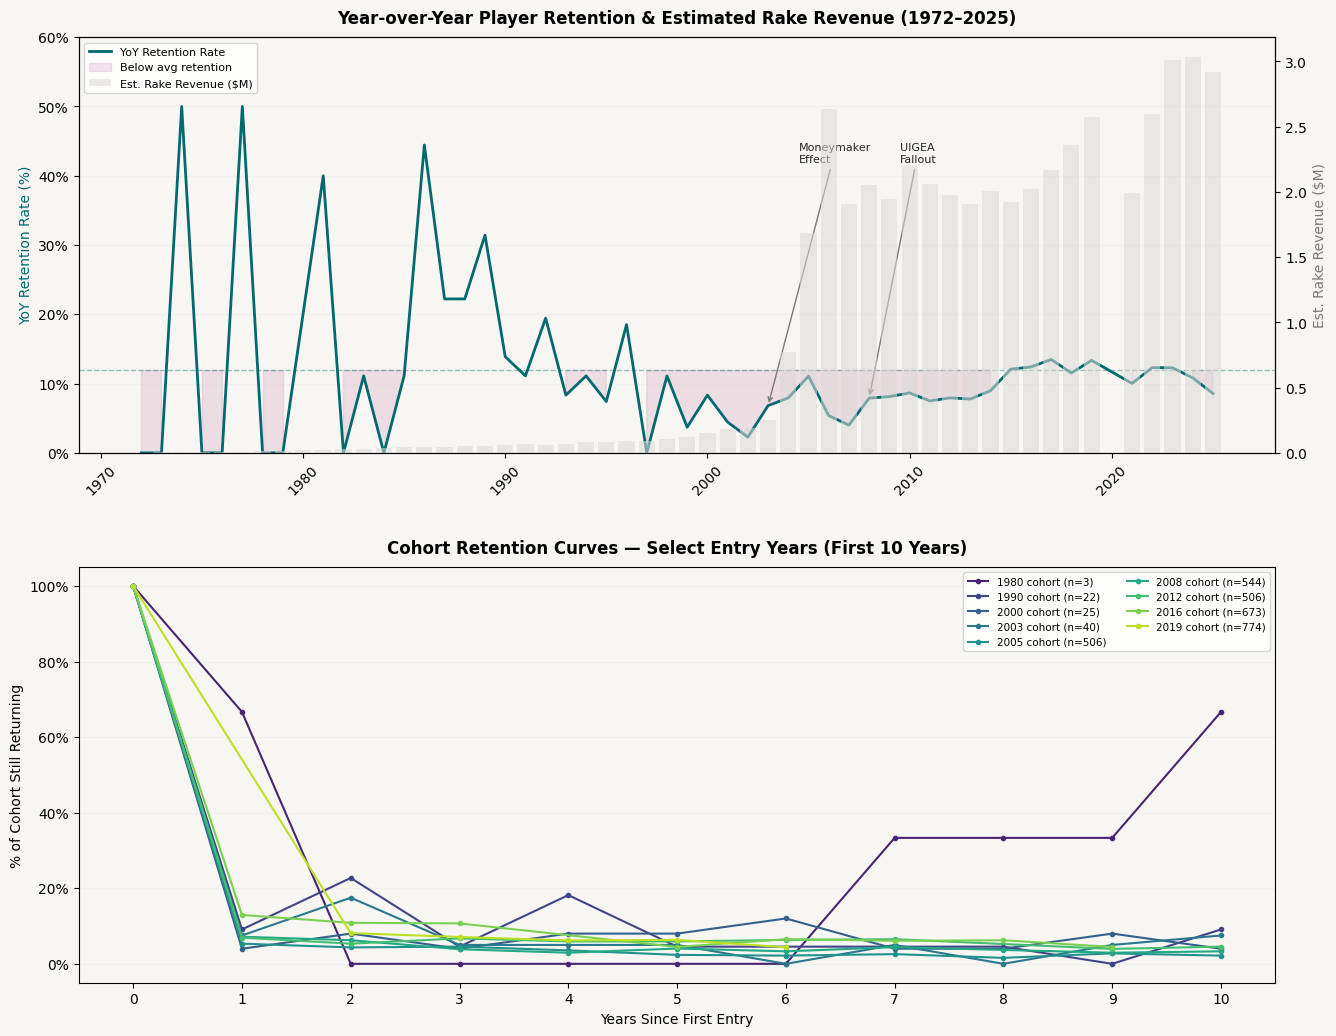

In [34]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(2, 1, figsize=(14, 11))
fig.patch.set_facecolor('#f7f6f2')

# --- Plot 1: YoY retention rate ---
ax1 = axes[0]
ax1.set_facecolor('#f7f6f2')

yearly_entries = df.groupby('year')[['entries','buyin']].first().reset_index()
ax2 = ax1.twinx()

retention = yoy_df['yoy_retention_rate'] * 100
ax1.plot(yoy_df['year'], retention, color='#01696f', linewidth=2, zorder=3, label='YoY Retention Rate')
ax1.axhline(y=retention.mean(), color='#01696f', linewidth=1, linestyle='--', alpha=0.4)
ax1.fill_between(yoy_df['year'], retention, retention.mean(),
                 where=(retention < retention.mean()),
                 alpha=0.12, color='#a12c7b', label='Below avg retention')

rake_plot = yearly_entries[yearly_entries['year'].isin(yoy_df['year'])]
ax2.bar(rake_plot['year'], rake_plot['entries'] * rake_plot['buyin'] * 0.03 / 1e6,
        color='#dcd9d5', alpha=0.55, width=0.8, zorder=1, label='Est. Rake Revenue ($M)')

ax1.set_ylabel('YoY Retention Rate (%)', color='#01696f', fontsize=10)
ax2.set_ylabel('Est. Rake Revenue ($M)', color='#7a7974', fontsize=10)
ax1.set_title('Year-over-Year Player Retention & Estimated Rake Revenue (1972–2025)',
              fontsize=12, fontweight='bold', pad=10)
ax1.set_ylim(0, 60)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

for anno_year, label, y_offset in [(2003, 'Moneymaker\nEffect', 42), (2008, 'UIGEA\nFallout', 42)]:
    if anno_year in yoy_df['year'].values:
        val = retention[yoy_df['year'] == anno_year].values[0]
        ax1.annotate(label, xy=(anno_year, val),
                     xytext=(anno_year + 1.5, y_offset), fontsize=8, color='#28251d',
                     arrowprops=dict(arrowstyle='->', color='#7a7974', lw=1), ha='left')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8, framealpha=0.8)
ax1.grid(axis='y', alpha=0.2, color='#dcd9d5')
ax1.tick_params(axis='x', rotation=45)

# --- Plot 2: Cohort survival curves ---
ax3 = axes[1]
ax3.set_facecolor('#f7f6f2')

highlight_cohorts = [1980, 1990, 2000, 2003, 2005, 2008, 2012, 2016, 2019]
palette = plt.cm.viridis(np.linspace(0.1, 0.9, len(highlight_cohorts)))

for cohort, color in zip(highlight_cohorts, palette):
    cdata = retention_df[
        (retention_df['cohort_year'] == cohort) &
        (retention_df['years_since_entry'] <= 10)
    ].copy()
    if len(cdata) > 1:
        ax3.plot(cdata['years_since_entry'], cdata['retention_rate'] * 100,
                 marker='o', markersize=3, linewidth=1.5, color=color,
                 label=f"{cohort} cohort (n={cdata['cohort_size'].iloc[0]:,})")

ax3.set_xlabel('Years Since First Entry', fontsize=10)
ax3.set_ylabel('% of Cohort Still Returning', fontsize=10)
ax3.set_title('Cohort Retention Curves — Select Entry Years (First 10 Years)',
              fontsize=12, fontweight='bold', pad=10)
ax3.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax3.legend(fontsize=7.5, loc='upper right', framealpha=0.8, ncol=2)
ax3.grid(axis='y', alpha=0.2, color='#dcd9d5')
ax3.set_xticks(range(0, 11))

plt.tight_layout(pad=3.0)
plt.savefig('wsop_retention_analysis.png', dpi=150, bbox_inches='tight', facecolor='#f7f6f2')
plt.show()

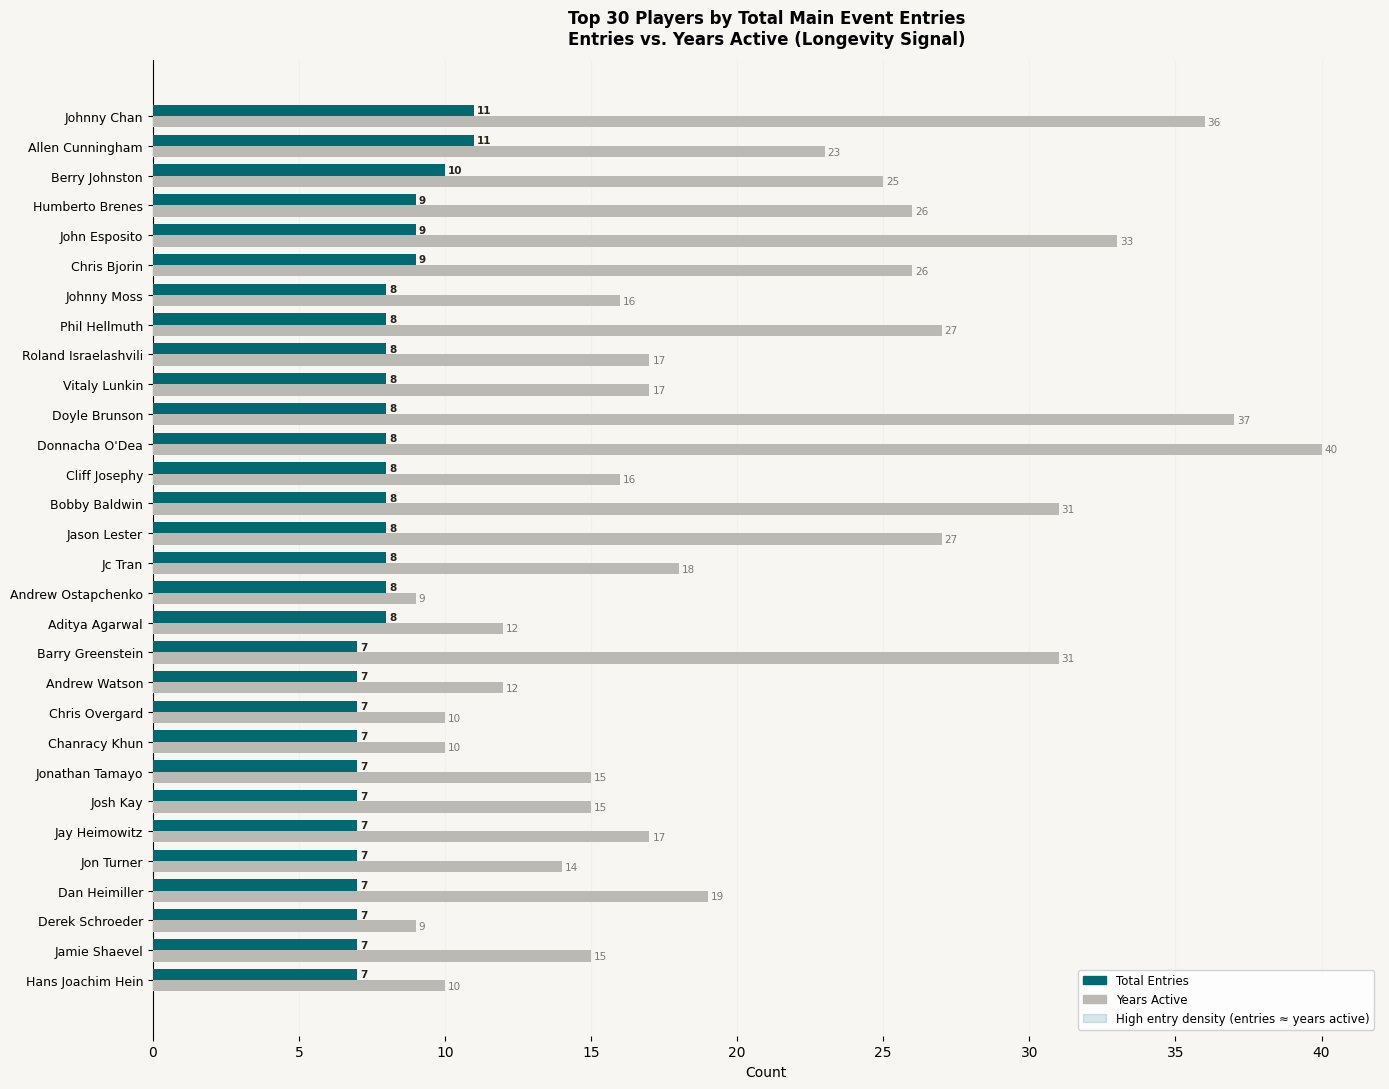

Chart saved.


In [36]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Top 30 by total entries
top_players = player_ltv.nlargest(30, 'total_entries').copy()
top_players = top_players.sort_values('total_entries', ascending=True)  # for horizontal bar

fig, ax = plt.subplots(figsize=(14, 11))
fig.patch.set_facecolor('#f7f6f2')
ax.set_facecolor('#f7f6f2')

y = np.arange(len(top_players))
bar_h = 0.38

# Bar 1: Total entries (teal)
bars1 = ax.barh(y + bar_h/2, top_players['total_entries'],
                height=bar_h, color='#01696f', label='Total Entries', zorder=3)

# Bar 2: Years active (warm gray)
bars2 = ax.barh(y - bar_h/2, top_players['years_active'],
                height=bar_h, color='#bab9b4', label='Years Active', zorder=3)

# Value labels
for i, (entries, years) in enumerate(zip(top_players['total_entries'], top_players['years_active'])):
    ax.text(entries + 0.1, i + bar_h/2, str(entries),
            va='center', fontsize=7.5, color='#28251d', fontweight='bold')
    ax.text(years + 0.1, i - bar_h/2, str(years),
            va='center', fontsize=7.5, color='#7a7974')

# Highlight players where entries >> years_active (high-volume, low-longevity)
for i, row in enumerate(top_players.itertuples()):
    ratio = row.total_entries / max(row.years_active, 1)
    if ratio >= 1.8:  # entered almost every year they were active or more
        ax.axhspan(i - 0.5, i + 0.5, alpha=0.06, color='#01696f', zorder=0)

ax.set_yticks(y)
ax.set_yticklabels(top_players['name'], fontsize=9)
ax.set_xlabel('Count', fontsize=10)
ax.set_title('Top 30 Players by Total Main Event Entries\nEntries vs. Years Active (Longevity Signal)',
             fontsize=12, fontweight='bold', pad=12)

entry_patch = mpatches.Patch(color='#01696f', label='Total Entries')
years_patch = mpatches.Patch(color='#bab9b4', label='Years Active')
highlight_patch = mpatches.Patch(color='#01696f', alpha=0.15,
                                  label='High entry density (entries ≈ years active)')
ax.legend(handles=[entry_patch, years_patch, highlight_patch],
          loc='lower right', fontsize=8.5, framealpha=0.85)

ax.grid(axis='x', alpha=0.2, color='#dcd9d5', zorder=0)
ax.spines[['top','right','bottom']].set_visible(False)

plt.tight_layout()
plt.savefig('wsop_top_players_entries_vs_longevity.png', dpi=150,
            bbox_inches='tight', facecolor='#f7f6f2')
plt.show()
print("Chart saved.")

### Re-Engagement Discount Scenario: Targeting Lapsed High-LTV Players

Not all lapsed players are equal. A player who entered 8 times over 12 years — spending $80,000 in buy-ins — is categorically different from someone who entered once in 2006 and never came back. Consumer platforms like FanDuel segment exactly this way: high-frequency, high-spend users who have gone dormant are the highest-ROI re-engagement target precisely because their historical behavior demonstrates genuine willingness to pay.

The table below models what a 5% or 10% re-entry discount would cost WSOP per recovered player, and at what lifetime spend level the economics clearly favor the intervention. The key insight: for any player with 3+ prior entries, a $500–$1,000 discount is a rounding error relative to the rake revenue they represent.

In [35]:
buyin_2025 = 10_000
discount_rates = [0.05, 0.10]

seg_stats = player_ltv[player_ltv['lapsed']].groupby('segment').agg(
    player_count    = ('name', 'count'),
    avg_entries     = ('total_entries', 'mean'),
    avg_lifetime_spend = ('lifetime_buyin', 'mean'),
).reset_index()

rows = []
for _, seg in seg_stats.iterrows():
    for disc in discount_rates:
        discount_cost     = buyin_2025 * disc
        rake_if_returns   = buyin_2025 * 0.03
        net_rake          = rake_if_returns - discount_cost
        breakeven_conv    = discount_cost / rake_if_returns  # fraction of pool needed to break even
        rows.append({
            'Segment'               : seg['segment'],
            'Lapsed Players'        : f"{int(seg['player_count']):,}",
            'Avg Lifetime Spend'    : f"${seg['avg_lifetime_spend']:,.0f}",
            'Avg Prior Entries'     : f"{seg['avg_entries']:.1f}",
            'Discount Offered'      : f"{int(disc*100)}% (${int(discount_cost):,})",
            'Rake if Returns'       : f"${int(rake_if_returns):,}",
            'Net Rake After Disc'   : f"${int(net_rake):,}" if net_rake > 0 else "Loss",
            'Break-even Conv. Rate' : f"{breakeven_conv*100:.0f}% of lapsed pool",
        })

scenario_df = pd.DataFrame(rows)
print(scenario_df.to_string(index=False))

                Segment Lapsed Players Avg Lifetime Spend Avg Prior Entries Discount Offered Rake if Returns Net Rake After Disc Break-even Conv. Rate
High-Value (5+ entries)            113            $57,389               5.7        5% ($500)            $300                Loss   167% of lapsed pool
High-Value (5+ entries)            113            $57,389               5.7     10% ($1,000)            $300                Loss   333% of lapsed pool
 Mid-Tier (2–4 entries)          2,157            $24,029               2.4        5% ($500)            $300                Loss   167% of lapsed pool
 Mid-Tier (2–4 entries)          2,157            $24,029               2.4     10% ($1,000)            $300                Loss   333% of lapsed pool


## Output Tables

The notebook exports refreshed derived tables so reviewers can inspect the analysis outputs without rerunning every cell.

These outputs are useful because they separate final artifacts from intermediate notebook logic. A reviewer can inspect the processed economics panel, champion labels, heads-up labels, and simulation outputs directly.

In [31]:
# Export refreshed derived tables.
key_metrics.to_csv(PROCESSED / 'wsop_key_metrics.csv', index=False)
era_summary.to_csv(PROCESSED / 'wsop_era_champion_status_summary.csv', index=False)
heads_up_pivot.to_csv(PROCESSED / 'wsop_headsup_mix_by_year.csv', index=False)
heads_up_mix_counts.to_csv(PROCESSED / 'wsop_headsup_mix_counts.csv', index=False)
uncertainty_stress_test.to_csv(PROCESSED / 'wsop_uncertainty_stress_test.csv', index=False)

exports = sorted([p.relative_to(ROOT).as_posix() for p in PROCESSED.glob('*.csv')]) + sorted([p.relative_to(ROOT).as_posix() for p in LABELS.glob('*.csv')]) + sorted([p.relative_to(ROOT).as_posix() for p in CHARTS.glob('*.png')])
pd.DataFrame({'exported_file': exports})

,exported_file
0,data/processed/wsop_dataset_reconciliation_detail.csv
1,data/processed/wsop_dataset_reconciliation_summary.csv
2,data/processed/wsop_era_champion_status_summary.csv
3,data/processed/wsop_headsup_mix_by_year.csv
4,data/processed/wsop_headsup_mix_counts.csv
5,data/processed/wsop_key_metrics.csv
6,data/processed/wsop_simulated_player_cohort.csv
7,data/processed/wsop_uncertainty_stress_test.csv
8,data/processed/wsop_yearly_economics_with_status.csv
9,data/labels/wsop_champion_eventtime_labels.csv


## Findings

1. **Scale changed the economics of the Main Event.**  
   The tournament expanded from a small-field competition into a mass-market event, changing the interpretation of field size, payout structure, and participant outcomes.

2. **Winner concentration declined as the event matured.**  
   The first-place prize remained large in absolute terms, but the winner's share of the total prize pool declined as participation expanded.

3. **Fee drag is a first-order economic force.**  
   Rake is built into the system and affects expected value before competition even begins.

4. **Professional players dominate, but amateur cases matter.**  
   Most champion and heads-up outcomes involve professional players, but amateur and uncertain-crossover cases are historically important and analytically meaningful.

5. **Event-time labels are more defensible than lifetime labels.**  
   A player's status at the time of the event can differ from their later career identity, which is why the project keeps labels separate from the raw results.

6. **Skill exists, but realized performance is noisy.**  
   The simulation produces a positive but imperfect relationship between underlying skill and realized outcomes.

7. **Small samples are dangerous.**  
   The ROI distribution by entry count shows why early performance can be misleading. This lesson generalizes to business settings where teams over-interpret outcomes from too little data.

## Limitations

- The Kaggle-derived source files contain tournament results, not complete player occupation histories.
- Professional/amateur status is handled through a separate event-time label layer, supported by AI-assisted research and manual review.
- Labels include confidence levels because some players are ambiguous or changed status over time.
- Name normalization reduces spelling mismatches but cannot fully eliminate identity-resolution risk.
- 1970 and 2020 require special caution because they do not fit cleanly into the standard modern Main Event structure.
- Estimated rake is derived from available entries, buy-in, and prize-pool fields; it should be interpreted as an analytical estimate rather than a complete accounting reconstruction.
- The simulation is illustrative. It is used to show skill-versus-variance dynamics, not to estimate actual player skill from observed WSOP outcomes.

## Conclusion

The most interesting question is not whether poker is "skill" or "luck" in a simplistic binary sense.

The more useful framing is whether skill can be economically meaningful in a noisy system with structural friction.

This analysis suggests that the answer is yes, but only with patience, scale, and disciplined interpretation.

The WSOP Main Event is a useful case study because the economics are visible. Field size, buy-in, payout structure, rake, player composition, and outcomes can all be examined together.

The broader analytical lesson is that many business problems have the same structure. The hard part is not merely measuring outcomes. The hard part is distinguishing durable edge from randomness while accounting for incentives, sample size, and fee drag.